# 活性化関数（Activation）
---
## 目的
深層学習における活性化関数を理解し，勾配消失問題に対処する様子や非線形変換について確認する．

In [1]:
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt

### 深層学習と活性化関数
深層学習における全結合は，入出力が線形な関係性である場合は観測データをうまく近似することができます．（左図）
しかし，入出力が非線形な関係性である場合は，線形結合のみを用いた表現ではうまく近似することができません．（右図）

<left>
<img src=https://onedrive.live.com/embed?resid=B8367B1E7E59C516%21562398&authkey=%21AIIIZRomunw6hBE&width=1783&height=787
width=90%>
<br>
</left>

また，深層学習ではパラメータ更新に勾配が重要な役割を果たします．<br>
しかし，誤差逆伝搬では特定の層の勾配を求めるために，$（特定の層の勾配）＝（1層前の勾配）\times （2層前の勾配）\times \cdots \times（出力層の勾配）$と積の形をとります．<br>
そのため，ある層の勾配が小さいと入力層付近の層の勾配は$0$に近づいてしまいます．<br>
これを勾配消失問題といい，ネットワークの層が増えるほど致命的な課題となります．

**勾配消失問題**：損失関数のパラメータ微分値が数値計算上極めて小さくなってしまい，学習が進まなくなる問題．

上記の問題に効率的に対処するために，深層学習では活性化関数が導入されています．<br>
次に，基本的な活性化関数を紹介する．

---
### Step Function (単位ステップ関数)<br>

単位ステップ関数は，あらゆる入力値を$0$もしくは$1$の数値に変換して出力する関数である．<br>
ニューラルネットワークの基礎モデルであるパーセプトロンでは活性化関数として「ステップ関数」が用いられていた．
しかし，ステップ関数はほとんどの点で勾配が0であるため，逆伝搬において勾配降下法を用いることができない．<br>

$$H(x) = \begin{cases}
1, & \text{if } x > 0 \\
0, & \text{if } x \leq 0
\end{cases}$$


In [2]:
# シグモイド関数の定義
def step(x):
    return  np.where(x >= 0, 1, 0)

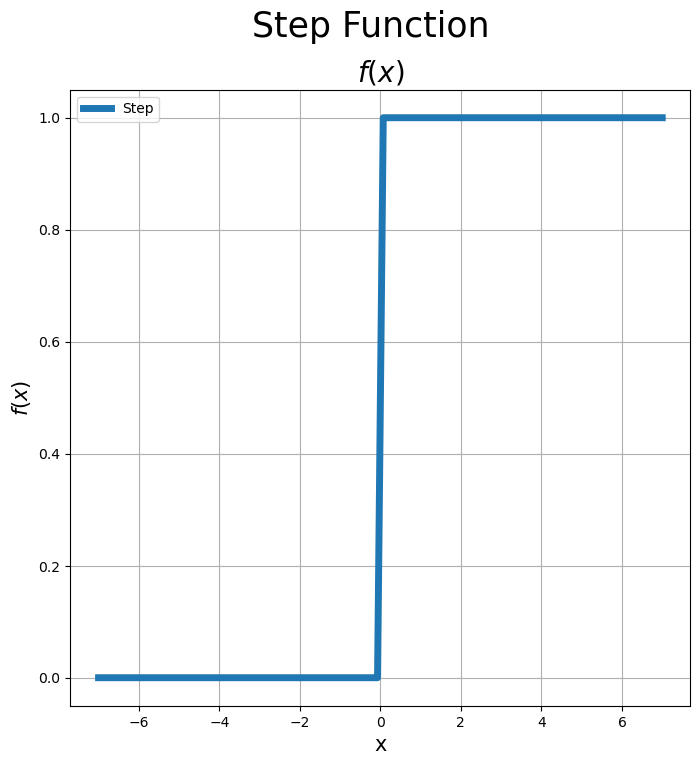

In [3]:
# グラフのプロット
x = np.linspace(-7, 7, 100)

# シグモイド関数を計算
y = step(x)

fig = plt.figure(figsize=(8, 8))
fig.suptitle("Step Function", fontsize=25)

ax = fig.add_subplot(111)
ax.plot(x, y, label="Step", linewidth=5)
ax.set_title('$f(x)$', fontsize=20)
ax.set_xlabel('x', fontsize=15)
ax.set_ylabel('$f(x)$', fontsize=15)
ax.legend()
ax.grid(True)



---
### Logistic Sigmoid Function (Sigmoid Function, シグモイド関数)<br>

シグモイド関数は，あらゆる入力値を$0.0\sim1.0$の範囲の数値に変換して出力する関数である．<br>
ニューラルネットワークの基礎モデルであるパーセプトロンでは活性化関数として「ステップ関数」が用いられていた．
しかし，ステップ関数はほとんどの点で勾配が0であるため，逆伝搬において勾配降下法を用いることができませんでした．<br>
そこで，微分可能な活性化関数として「シグモイド関数」が利用されるようになりました．

$$\sigma(\boldsymbol{x})=\frac{1}{1+\exp(-\boldsymbol{x})}$$

また，シグモイド関数の導関数についても定義します．
$$\frac{d}{dx} \sigma(\boldsymbol{x})=(1-\sigma(\boldsymbol{x}))\cdot \sigma(\boldsymbol{x})$$

**【導出】**<br>
$$\sigma(\boldsymbol{x})=(1+\exp(-\boldsymbol{x}))^{-1}$$
ここで，$\boldsymbol{u}=1+\exp(-\boldsymbol{x})$とすると，
$\sigma(\boldsymbol{x})=\boldsymbol{u}^{-1}$

$$\begin{align}
\nabla \sigma(\boldsymbol{x})&=\frac{\partial f}{\partial u} \frac{\partial u}{\partial x} \notag\\
&=(-\boldsymbol{u}^{-2}) \cdot (-\exp(-\boldsymbol{x})) \notag\\
&=(1+\exp(-\boldsymbol{x}))^{-2} \cdot \exp(-\boldsymbol{x})
\notag \\
&= \frac{\exp(-\boldsymbol{x})}{1+\exp(-\boldsymbol{x})} \cdot \frac{1}{1+\exp(-\boldsymbol{x})} \notag \\
&= (\frac{1+\exp(-\boldsymbol{x})}{1+\exp(-\boldsymbol{x})}-\frac{1}{1+\exp(-\boldsymbol{x})})\cdot \frac{1}{1+\exp(-\boldsymbol{x})} \notag \\
&= (1-\sigma(\boldsymbol{x}))\cdot \sigma(\boldsymbol{x}) \notag
\end{align}$$


In [4]:
# シグモイド関数の定義
def sigmoid(x):
    return 1 / (1 + np.exp(-x))

def sigmoid_grad(x):
    return (1.0 - sigmoid(x)) * sigmoid(x)

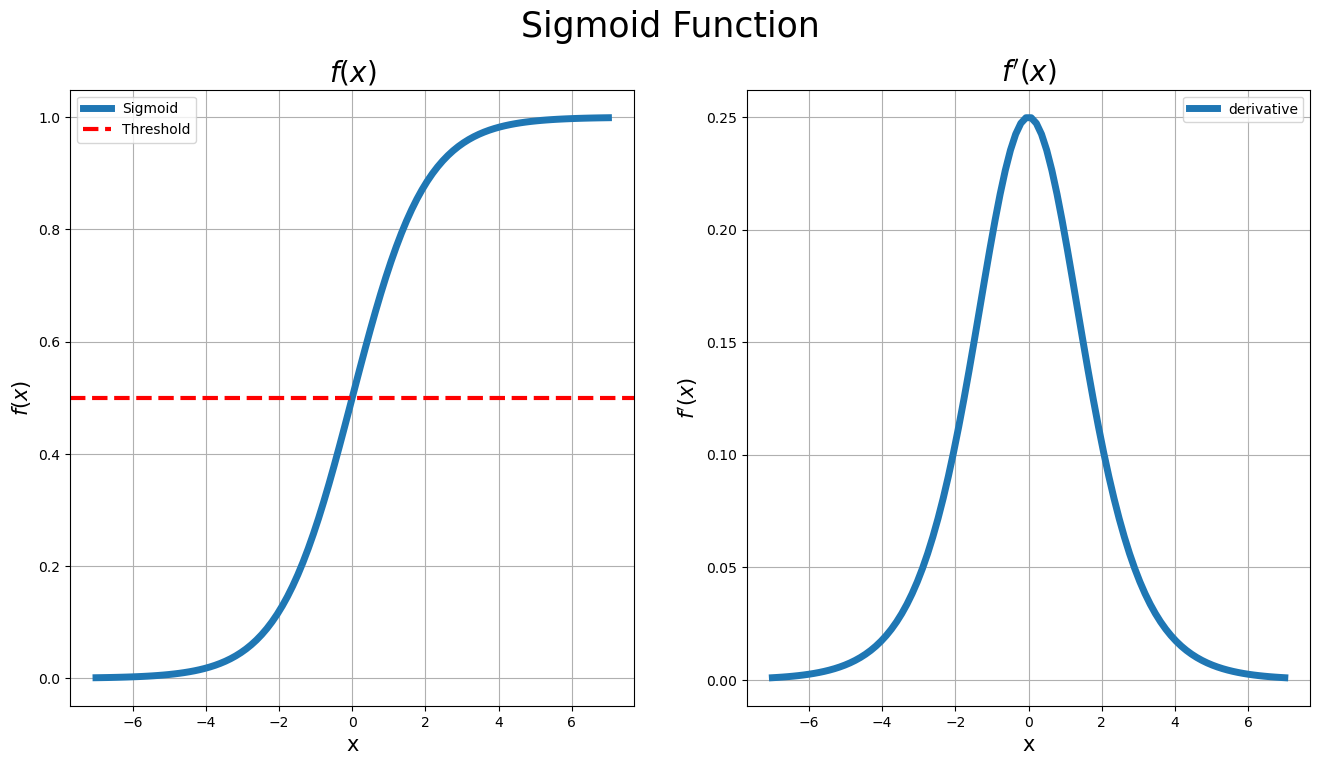

In [5]:
def plot_activation(x,y,y_,thr,fig_txt,label1,label2):
    fig = plt.figure(figsize=(16, 8))
    fig.suptitle(fig_txt, fontsize=25)

    ax = fig.add_subplot(121)
    ax.plot(x, y, label=label1, linewidth=5)
    ax.set_title('$f(x)$', fontsize=20)
    ax.set_xlabel('x', fontsize=15)
    ax.set_ylabel('$f(x)$', fontsize=15)
    ax.axhline(thr, color='red', linestyle='--', linewidth=3, label='Threshold')
    ax.legend()
    ax.grid(True)

    ax = fig.add_subplot(122)
    ax.plot(x, y_, label=label2, linewidth=5)
    ax.set_title('$f\'(x)$', fontsize=20)
    ax.set_xlabel('x', fontsize=15)
    ax.set_ylabel('$f\'(x)$', fontsize=15)
    ax.legend()
    ax.grid(True)

    plt.show()

# グラフのプロット
x = np.linspace(-7, 7, 100)

# シグモイド関数を計算
y = sigmoid(x)
y_ = sigmoid_grad(x)

plot_activation(x,y,y_,0.5,'Sigmoid Function','Sigmoid','derivative')

しかしながら，シグモイド関数は次の2つの問題点を抱えている：
* 勾配消失問題が生じる．なぜなら，（-4,4）以降の値で出力値が飽和するため微分値が0になるためである．
* 内部共分散シフト（Internal covariate shift）が生じる．図の赤点線をみるとわかるように，0.5中心の出力である（= 0中心の出力でない）．

---
### Hyperbolic tangent Function (tanh Function, Tanh関数)<br>

tanh関数は，シグモイド関数をスケーリングし，0中心へ平行移動させた関数である．<br>
つまり，tanh関数の出力は「0が中心」となり，シグモイド関数の問題点の一つを解決している．

$$\tanh(\boldsymbol{x})=\frac{\exp(\boldsymbol{x}) - \exp(-\boldsymbol{x})}{\exp(\boldsymbol{x}) + \exp(-\boldsymbol{x})}$$

また，tanh関数の導関数についても定義します．
$$\frac{d}{dx} \tanh(\boldsymbol{x})=1-\tanh^{2}(\boldsymbol{x})$$

**【導出】**<br>
$$\begin{align*}
\tanh(x) &= \frac{e^{x} - e^{-x}}{e^{x} + e^{-x}} \\
\tanh'(x) &= \frac{d}{dx} \left( \frac{e^{x} - e^{-x}}{e^{x} + e^{-x}} \right) \\
&= \frac{(e^{x} + e^{-x}) \cdot (e^{x} + e^{-x}) - (e^{x} - e^{-x}) \cdot (e^{x} - e^{-x})}{(e^{x} + e^{-x})^2} \\
&= \frac{(e^{x} + e^{-x})^2 - (e^{x} - e^{-x})^2}{(e^{x} + e^{-x})^2} \\
&= 1 - \frac{(e^{x} - e^{-x})^2}{(e^{x} + e^{-x})^2} \\
&= 1 - \tanh^2(x)
\end{align*}$$


In [6]:
# tanh関数の定義
def tahh(x):
    return np.tanh(x)

def tahh_grad(x):
    return  1 - tahh(x)**2

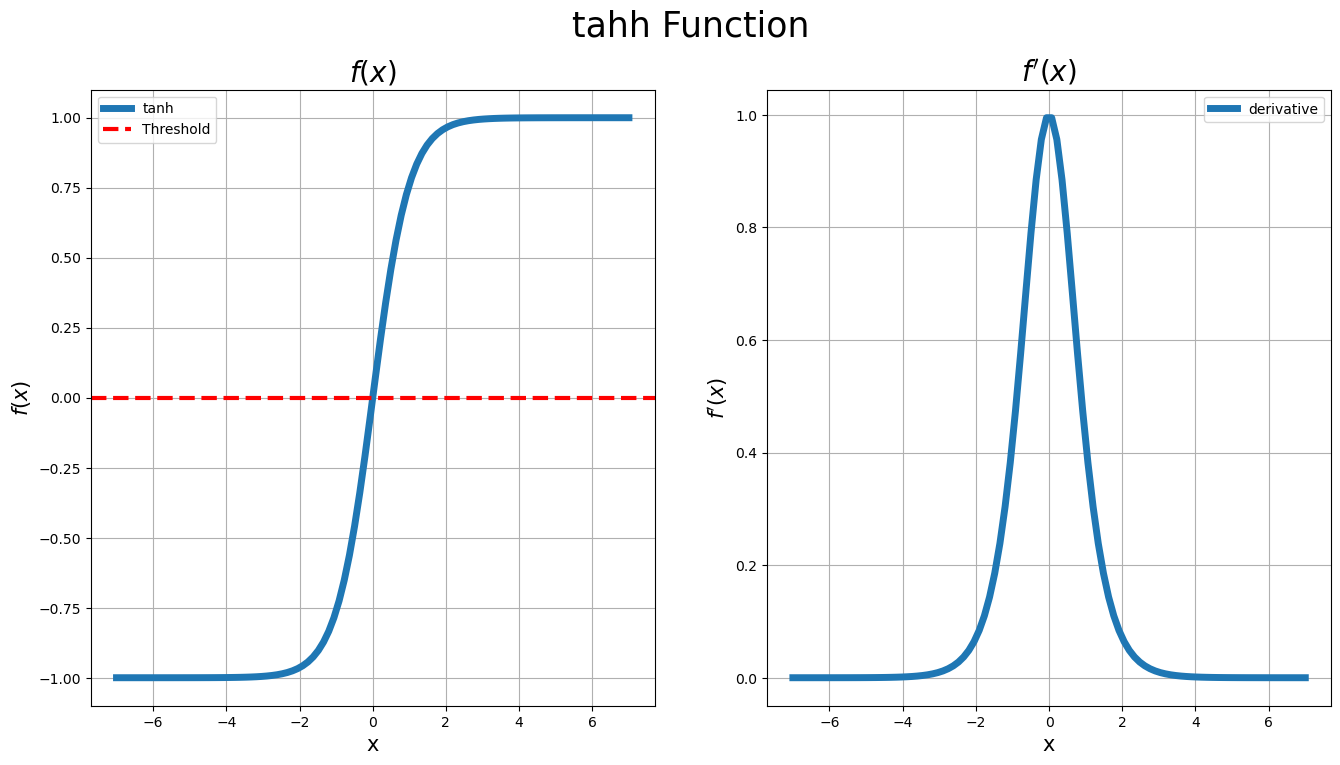

In [7]:
# グラフのプロット
x = np.linspace(-7, 7, 100)

# tanh関数を計算
y = tahh(x)
y_ = tahh_grad(x)

plot_activation(x,y,y_,0.0,'tahh Function','tanh','derivative')

tanh関数はシグモイド関数より勾配が大きく学習が早くなる利点がある．<br>
しかし，依然として勾配消失問題を抱えている

---
### Rectified Linear Unit Function (ReLU Function, Tanh関数)<br>

ReLU関数は，正の範囲は(押しつぶしを行なわずに)そのまま出力するのが特徴である．
逆に，負の範囲はステップ関数と同じになっており，全ての入力値を出力値0にして押しつぶす関数である．<br>
つまり，ReLU関数はシグモイド関数の二つの問題点を解決している．

$$\text{ReLU}(x) = \max(0, x)$$

また，ReLU関数の導関数についても定義します．
$$\frac{d}{dx} \text{ReLU}(x) = \begin{cases}
1, & \text{if } x > 0 \\
0, & \text{if } x \leq 0
\end{cases}$$

**【導出】**<br>
自明のため省略．
（$x=0$以外では微分可能である．）

In [8]:
# ReLU関数の定義
def relu(x):
    return np.maximum(0, x)

def relu_grad(x):
    return  1 * (x > 0)

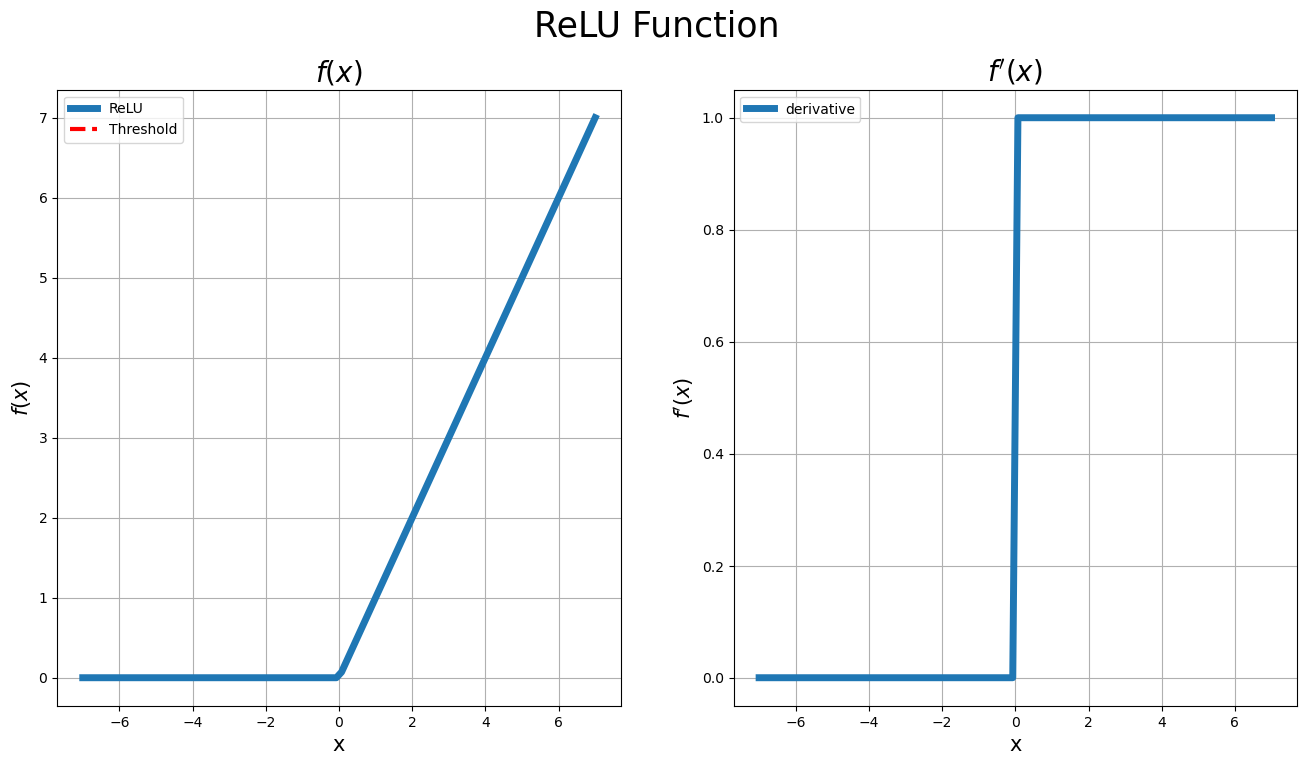

In [9]:
# グラフのプロット
x = np.linspace(-7, 7, 100)

# relu関数を計算
y = relu(x)
y_ = relu_grad(x)

plot_activation(x,y,y_,np.nan,'ReLU Function','ReLU','derivative')

CNNの中間層にはReLU型の活性化関数を用いることが定番化している．その理由は，正の範囲で微分値が全て1となるため，DNNの学習の収束時間が早くなることにある．<br>
これにより，シグモイドやtanhのように「勾配が0に飽和して学習が進行しなくなる」こともなく，勾配消失も生じない．つまり，深いDNNでもしっかりと大きな量の勾配を，序盤の層まで逆伝搬できるようになった．